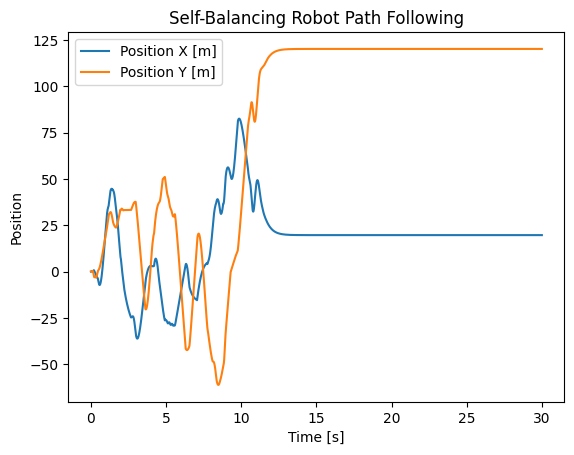

In [1]:
import pybullet
import pybullet_data
import numpy as np
import time
import matplotlib.pyplot as plt

# Connect to PyBullet and setup environment
pybullet.connect(pybullet.GUI)
pybullet.setAdditionalSearchPath(pybullet_data.getDataPath())
pybullet.setGravity(0, 0, -9.8)

# Load plane and set up surface friction
plane_id = pybullet.loadURDF("plane.urdf")
# Set friction parameters for the plane
plane_static_friction = 1.0
plane_dynamic_friction = 0.1

pybullet.changeDynamics(plane_id, -1,lateralFriction=plane_static_friction,spinningFriction=plane_dynamic_friction)

# Load the robot
robot_id = pybullet.loadURDF("twsbr_env/envs/urdf/twsbr_v2.urdf")
# Define the indices of the wheels
wheel_indices = [0, 1]

# Set friction parameters for each wheel (simulating rubber wheels)
static_friction = 1.0
dynamic_friction = 0.5

for wheel_index in wheel_indices:
    pybullet.changeDynamics(robot_id, wheel_index,
                     lateralFriction=static_friction,
                     spinningFriction=dynamic_friction)
                     
# Fullscreen window and hide default visual elements
pybullet.configureDebugVisualizer(pybullet.COV_ENABLE_GUI, 0)
pybullet.resetDebugVisualizerCamera(cameraDistance=1, cameraYaw=45, cameraPitch=-30, cameraTargetPosition=[0, 0, 0])

# Define motor indices
left_wheel_joint = 0
right_wheel_joint = 1

# PID controller parameters for balance, steering, and distance
Kp_balance = 25.0
Kd_balance = 0.1
Ki_balance = 0.001

Kp_steer = 0.1
Kd_steer = 0.01
Ki_steer = 0.001

Kp_distance = 0.1
Kd_distance = 0.01
Ki_distance = 0.001

# Variables for PID calculations
integral_balance = 0.0

prev_error_balance = 0.0

integral_steer = 0.0
prev_error_steer = 0.0

integral_distance = 0.0
prev_error_distance = 0.0

# Define target positions
target_positions = [(1, 0, 0), (2, 0, 0), (2, 1, 0), (2, 2, 0)]
current_target_index = 0

# Simulation parameters
dt = 1. / 1000.
t = np.arange(0, 30, dt)
states = []

# Functions for PID calculations
def pid_distance(current_position, target_position):
    global integral_distance, prev_error_distance
    error = np.linalg.norm(np.array(target_position[:2]) - np.array(current_position[:2]))  # Distance error in x-y plane
    integral_distance += error * dt
    derivative = (error - prev_error_distance) / dt
    prev_error_distance = error
    return Kp_distance * error + Ki_distance * integral_distance + Kd_distance * derivative

def pid_balance(current_angle, target_angle=0.0):
    global integral_balance, prev_error_balance
    error = target_angle - current_angle
    integral_balance += error * dt
    derivative = (error - prev_error_balance) / dt
    prev_error_balance = error
    return Kp_balance * error + Ki_balance * integral_balance + Kd_balance * derivative

def pid_steer(current_angle, target_angle):
    global integral_steer, prev_error_steer
    error = target_angle - current_angle
    integral_steer += error * dt
    derivative = (error - prev_error_steer) / dt
    prev_error_steer = error
    return Kp_steer * error + Ki_steer * integral_steer + Kd_steer * derivative

# Display function for robot state
def display_robot_state_in_window(roll_deg, pitch_deg, yaw_deg, x, y, z, x_dot, y_dot, z_dot, left_linear_velocity, right_linear_velocity):
    text_lines = [
        f"Roll: {roll_deg:.2f}°",
        f"Pitch: {pitch_deg:.2f}°",
        f"Yaw: {yaw_deg:.2f}°",
        f"Position (X, Y, Z): ({x:.2f}, {y:.2f}, {z:.2f}) m",
        f"Velocity (X, Y, Z): ({x_dot:.2f}, {y_dot:.2f}, {z_dot:.2f}) m/s",
        f"Left Wheel Velocity: {left_linear_velocity:.2f} m/s",
        f"Right Wheel Velocity: {right_linear_velocity:.2f} m/s",
    ]
    
    for i, line in enumerate(text_lines):
        pybullet.addUserDebugText(line, [x, y, 0.2 + i * 0.05], lifeTime=0.2, textSize=1, textColorRGB=[0, 0, 0])


# Add axis lines at origin
axis_length = 0.5  # Length of each axis
line_width = 2     # Line width

# X-axis (red)
pybullet.addUserDebugLine([0, 0, 0], [axis_length, 0, 0], [1, 0, 0], lineWidth=line_width)
# Y-axis (green)
pybullet.addUserDebugLine([0, 0, 0], [0, axis_length, 0], [0, 1, 0], lineWidth=line_width)
# Z-axis (blue)
pybullet.addUserDebugLine([0, 0, 0], [0, 0, axis_length], [0, 0, 1], lineWidth=line_width)

# Main simulation loop
for time_step in t:
    pos, orn = pybullet.getBasePositionAndOrientation(robot_id)
    linear_velocity, angular_velocity = pybullet.getBaseVelocity(robot_id)

    roll, pitch, yaw = pybullet.getEulerFromQuaternion(orn)
    roll_deg = np.degrees(roll)
    pitch_deg = np.degrees(pitch)
    yaw_deg = np.degrees(yaw)
    
    x, y, z = pos
    x_dot, y_dot, z_dot = linear_velocity

    # Check if the robot has reached the current target position
    target_position = target_positions[current_target_index]
    distance_to_target = np.linalg.norm(np.array(target_position[:2]) - np.array([x, y]))
    
    if distance_to_target < 0.1:  # Move to next target if within threshold
        current_target_index = (current_target_index + 1) % len(target_positions)
        target_position = target_positions[current_target_index]

    # Calculate desired distance and steering adjustments
    distance_output = pid_distance((x, y, z), target_position)
    angle_to_target = np.arctan2(target_position[1] - y, target_position[0] - x)
    steer_output = pid_steer(yaw_deg, np.degrees(angle_to_target))

    # Balancing PID
    balance_output = pid_balance(pitch_deg, 0.0)

    # Set wheel velocities
    left_wheel_velocity = balance_output #+ steer_output
    right_wheel_velocity = balance_output #- steer_output

    pybullet.setJointMotorControl2(robot_id, left_wheel_joint, pybullet.VELOCITY_CONTROL, targetVelocity=-left_wheel_velocity)
    pybullet.setJointMotorControl2(robot_id, right_wheel_joint, pybullet.VELOCITY_CONTROL, targetVelocity=-right_wheel_velocity)

    left_wheel_velocity = pybullet.getJointState(robot_id, left_wheel_joint)[1]
    right_wheel_velocity = pybullet.getJointState(robot_id, right_wheel_joint)[1]
    
    wheel_radius = 0.045
    left_linear_velocity = left_wheel_velocity * wheel_radius
    right_linear_velocity = right_wheel_velocity * wheel_radius

    #display_robot_state_in_window(roll_deg, pitch_deg, yaw_deg, x, y, z, x_dot, y_dot, z_dot, left_linear_velocity, right_linear_velocity)

    states.append(np.array([pitch_deg, x, y, x_dot, y_dot]))
    pybullet.stepSimulation()

pybullet.disconnect()

# Plotting
states = np.array(states)
plt.figure()
plt.plot(t[:len(states)], states[:, 1], label='Position X [m]')
plt.plot(t[:len(states)], states[:, 2], label='Position Y [m]')
plt.xlabel('Time [s]')
plt.ylabel('Position')
plt.title('Self-Balancing Robot Path Following')
plt.legend()
plt.show()

In [1]:
import time
import math
import pybullet
import pybullet_data
physics_client = pybullet.connect(pybullet.GUI) 
import numpy as np
import cv2

pybullet.resetSimulation() # Reset the simulation space
pybullet.setAdditionalSearchPath(pybullet_data.getDataPath()) # Add path to necessary data for pybullet
pybullet.setGravity(0.0, 0.0, -9.8) # Set gravity as on Earth
time_step = 1./240.
pybullet.setTimeStep(time_step)
# Load the floor

plane_id = pybullet.loadURDF("plane.urdf", basePosition=[8.25, 4.5, 0.0], globalScaling=5.0)
tex_uid = pybullet.loadTexture("twsbr_env/envs/texture/random_line_trace_ground.png")
pybullet.changeVisualShape(plane_id, -1, textureUniqueId=tex_uid)
# Load the robot
robot_start_pos = [0.0, 0.0, 0.0]  # Set the initial position (x, y, z)
robot_start_orientation = pybullet.getQuaternionFromEuler([0, 0, 0])  # Set the initial orientation (roll, pitch, yaw)
robot_id = pybullet.loadURDF("twsbr_env/envs/urdf/twsbr_v2.urdf", robot_start_pos, robot_start_orientation)

# Set the camera position and other parameters in GUI mode
camera_distance = 6.0
camera_yaw = 0.0 # deg
camera_pitch = -90.1 # deg
camera_target_position = [2.5, 0.0, 0.0]
pybullet.resetDebugVisualizerCamera(camera_distance, camera_yaw, camera_pitch, camera_target_position)


# Define rotation matrices used to calculate the cameraUpVector according to the movement of the mobile robot
def Rx(theta):
    return np.array([[1, 0, 0],
                     [0, np.cos(theta), -np.sin(theta)],
                     [0, np.sin(theta), np.cos(theta)]])

def Ry(theta):
    return np.array([[np.cos(theta), 0, np.sin(theta)],
                     [0, 1, 0],
                     [-np.sin(theta), 0, np.cos(theta)]])

def Rz(theta):
    return np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta), np.cos(theta), 0],
                     [0, 0, 1]])

# Set the robot to the initial position
robot_start_pos = [0.0, 0, 0.0]
robot_start_orientation = pybullet.getQuaternionFromEuler([0.0, 0.0, -math.pi/2])
pybullet.resetBasePositionAndOrientation(robot_id, robot_start_pos, robot_start_orientation)

# Set the time length
time_length = 10000

# Bottom camera settings
projection_matrix = pybullet.computeProjectionMatrixFOV(fov=140.0, aspect=1.0, nearVal=0.01, farVal=100)
    
# Link indices
CAMERA_IDX = 2
CAMERA_TARGET_IDX = 3

# Joint indices
RIGHT_WHEEL_JOINT_IDX = 1
LEFT_WHEEL_JOINT_IDX = 0

# P control parameter
Kp = 0.1

# Base speed of the wheels
base_speed = 30

# Default direction of the camera_up_vector
camera_up_vector = np.array([0, -1, 0])

for t in range(time_length):
    # 1. Capture the image of the line from the bottom camera sensor ##########################################################
    # Get the position of the camera link
    camera_link_pose = pybullet.getLinkState(robot_id, CAMERA_IDX)[0]

    # Get the position of the virtual link for the target point
    camera_target_link_pose = pybullet.getLinkState(robot_id, CAMERA_TARGET_IDX)[0] 

    # Rotate the cameraUpVector according to the posture of the mobile robot
    mobile_robot_roll, mobile_robot_pitch, mobile_robot_yaw = pybullet.getEulerFromQuaternion(pybullet.getLinkState(robot_id, CAMERA_IDX)[1])
    R = Rz(np.deg2rad(90.0) + mobile_robot_yaw) @ Ry(mobile_robot_pitch) @ Rx(mobile_robot_roll)
    rotate_camera_up_vector = R @ camera_up_vector

    # Get the viewMatrix from the camera link to the virtual link for the target point
    view_matrix = pybullet.computeViewMatrix(cameraEyePosition=[camera_link_pose[0], camera_link_pose[1], camera_link_pose[2]], cameraTargetPosition=[camera_target_link_pose[0], camera_target_link_pose[1], camera_target_link_pose[2]], cameraUpVector=[rotate_camera_up_vector[0], rotate_camera_up_vector[1], rotate_camera_up_vector[2]])
    
    # Capture the image of the line
    # By specifying renderer=pybullet.ER_BULLET_HARDWARE_OPENGL, the image can be captured faster at the expense of quality
    width, height, rgb_img, depth_img, seg_img = pybullet.getCameraImage(600, 300, view_matrix, projection_matrix, renderer=pybullet.ER_BULLET_HARDWARE_OPENGL)
    ############################################################################################################

    # 2. Image processing (calculate the centroid position of the line) ########################################################################
    # Binarize the image
    img = np.reshape(rgb_img, (height, width, 4))  # Convert the captured image to a 4-channel numpy array
    img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)  # Convert from RGBA to RGB
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # Convert to grayscale
    _, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV) # Binarize

    # Calculate the centroid (reference: https://imagingsolution.net/program/python/opencv-python/opencv_moments_weight_center/)
    moments = cv2.moments(binary) 
    if moments["m00"] == 0: # Prevent division by zero
        cx = width / 2
    else:
        cx = moments["m10"] / moments["m00"]
    ############################################################################################################

    # 3. Adjust the speed of the wheels using P control based on the centroid position of the line #################################################
    # P control
    error = cx - (width / 2) # Distance from the "image center (x direction)" to the "centroid of the line (x direction)". The larger the deviation, the more the robot will turn right or left.
    output = Kp * error

    # Adjust the speed of the wheels
    right_speed = base_speed - output
    left_speed = base_speed + output
    
    # Set the speed of the wheels
    pybullet.setJointMotorControl2(robot_id, RIGHT_WHEEL_JOINT_IDX, pybullet.VELOCITY_CONTROL, targetVelocity=right_speed)
    pybullet.setJointMotorControl2(robot_id, LEFT_WHEEL_JOINT_IDX, pybullet.VELOCITY_CONTROL, targetVelocity=left_speed)
    ############################################################################################################

    # Advance the simulation by one time step
    pybullet.stepSimulation()
    time.sleep(time_step)

error: Not connected to physics server.

#Line Following Robot

In [1]:

import time
import math
import pybullet
import pybullet_data
physics_client = pybullet.connect(pybullet.GUI) 

pybullet.resetSimulation() # Reset the simulation space
pybullet.setAdditionalSearchPath(pybullet_data.getDataPath()) # Add path to necessary data for pybullet
pybullet.setGravity(0.0, 0.0, -9.8) # Set gravity as on Earth
time_step = 1./100.
pybullet.setTimeStep(time_step)

# Load the floor
plane_id = pybullet.loadURDF("plane.urdf", basePosition=[8.0, 4.5, 0.0], globalScaling=5.0)
tex_uid = pybullet.loadTexture("twsbr_env/envs/texture/random_line_trace_ground.png")
pybullet.changeVisualShape(plane_id, -1, textureUniqueId=tex_uid)

# Load the robot
robot_start_pos = [0.0, 0.0, 0.1]  # Set the initial position (x, y, z)
robot_start_orientation = pybullet.getQuaternionFromEuler([0, 0, 0])  # Set the initial orientation (roll, pitch, yaw)
robot_id = pybullet.loadURDF("twsbr_env/envs/urdf/line_follower_robot.urdf", robot_start_pos, robot_start_orientation)

# Set the camera position and other parameters in GUI mode
camera_distance = 6.0
camera_yaw = 45.0 # deg
camera_pitch = -45.1 # deg
camera_target_position = [2.5, 0.0, 0.0]
pybullet.resetDebugVisualizerCamera(camera_distance, camera_yaw, camera_pitch, camera_target_position)
# Define rotation matrices used to calculate the cameraUpVector according to the movement of the mobile robot
def Rx(theta):
    return np.array([[1, 0, 0],
                     [0, np.cos(theta), -np.sin(theta)],
                     [0, np.sin(theta), np.cos(theta)]])

def Ry(theta):
    return np.array([[np.cos(theta), 0, np.sin(theta)],
                     [0, 1, 0],
                     [-np.sin(theta), 0, np.cos(theta)]])

def Rz(theta):
    return np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta), np.cos(theta), 0],
                     [0, 0, 1]])

import numpy as np
import cv2

# Set the robot to the initial position
robot_start_pos = [0.0, 0, 0.05]
robot_start_orientation = pybullet.getQuaternionFromEuler([0.0, 0.0, math.pi/2])
pybullet.resetBasePositionAndOrientation(robot_id, robot_start_pos, robot_start_orientation)

# Set the time length
time_length = 10000

# Bottom camera settings
projection_matrix = pybullet.computeProjectionMatrixFOV(fov=140.0, aspect=1.0, nearVal=0.01, farVal=100)
    
# Link indices
CAMERA_IDX = 3
CAMERA_TARGET_IDX = 4

# Joint indices
RIGHT_WHEEL_JOINT_IDX = 0
LEFT_WHEEL_JOINT_IDX = 1

# Base speed of the wheels
base_speed = 40
max_speed = 250

# Default direction of the camera_up_vector
camera_up_vector = np.array([0, -1, 0])


integral_steer = 0.0
prev_error_steer = 0.0
Kp_steer = 10.0
Kd_steer = 0.5
Ki_steer = 0.1
dt = time_step

def pid_steer(error):
    global integral_steer, prev_error_steer
    error = error
    integral_steer += error * dt
    derivative = (error - prev_error_steer) / dt
    if error != 0.0 and abs(prev_error_steer) <= 4:
        prev_error_steer = error 
    #print(f"\r P: {(Kp_steer * error):.2f} , I : {(Ki_steer * integral_steer):.2f} , D: {(Kd_steer * derivative):.2f}" , end="")
    return Kp_steer * error + Ki_steer * integral_steer + Kd_steer * derivative


for t in range(time_length):

    # 1. Capture the image of the line from the bottom camera sensor ##########################################################
    # Get the position of the camera link
    camera_link_pose = pybullet.getLinkState(robot_id, CAMERA_IDX)[0]

    # Get the position of the virtual link for the target point
    camera_target_link_pose = pybullet.getLinkState(robot_id, CAMERA_TARGET_IDX)[0] 

    # Rotate the cameraUpVector according to the posture of the mobile robot
    mobile_robot_roll, mobile_robot_pitch, mobile_robot_yaw = pybullet.getEulerFromQuaternion(pybullet.getLinkState(robot_id, CAMERA_IDX)[1])
    R = Rz(np.deg2rad(90.0) + mobile_robot_yaw) @ Ry(mobile_robot_pitch) @ Rx(mobile_robot_roll)
    rotate_camera_up_vector = R @ camera_up_vector

    # Get the viewMatrix from the camera link to the virtual link for the target point
    view_matrix = pybullet.computeViewMatrix(cameraEyePosition=[camera_link_pose[0], camera_link_pose[1], camera_link_pose[2]], cameraTargetPosition=[camera_target_link_pose[0], camera_target_link_pose[1], camera_target_link_pose[2]], cameraUpVector=[rotate_camera_up_vector[0], rotate_camera_up_vector[1], rotate_camera_up_vector[2]])
    
    # Capture the image of the line
    # By specifying renderer=pybullet.ER_BULLET_HARDWARE_OPENGL, the image can be captured faster at the expense of quality
    width, height, rgb_img, depth_img, seg_img = pybullet.getCameraImage(8, 4, view_matrix, projection_matrix, renderer=pybullet.ER_BULLET_HARDWARE_OPENGL)
    ############################################################################################################

    # 2. Image processing (calculate the centroid position of the line) ########################################################################
    # Binarize the image
    img = np.reshape(rgb_img, (height, width, 4))  # Convert the captured image to a 4-channel numpy array
    img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)  # Convert from RGBA to RGB
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # Convert to grayscale
    _, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV) # Binarize

    # Calculate the centroid (reference: https://imagingsolution.net/program/python/opencv-python/opencv_moments_weight_center/)
    moments = cv2.moments(binary) 
    if moments["m00"] == 0: # Prevent division by zero
        cx = None
    else:
        cx = moments["m10"] / moments["m00"]
    ############################################################################################################

    # 3. Adjust the speed of the wheels using P control based on the centroid position of the line #################################################
    # P controlction)" to the "centroid of the line (x direction)". The larger the deviation, the more the robot will turn right or left.
    
    if cx is None:
        error = prev_error_steer
    else:
        error = cx - (width / 2)
        
    
    #output = Kp * error
    output = pid_steer(error)
    # Adjust the speed of the wheels
    right_speed = np.clip(base_speed - output, -max_speed, max_speed)
    left_speed = np.clip(base_speed + output, -max_speed, max_speed)
    print(f"\r error : {error:.2f} , prev error : {prev_error_steer:.2f}, output : {output:.2f} , left speed : {left_speed:.2f}, right speed : {right_speed:.2f}" , end="")
    # Set the speed of the wheels
    pybullet.setJointMotorControl2(robot_id, RIGHT_WHEEL_JOINT_IDX, pybullet.VELOCITY_CONTROL, targetVelocity=right_speed)
    pybullet.setJointMotorControl2(robot_id, LEFT_WHEEL_JOINT_IDX, pybullet.VELOCITY_CONTROL, targetVelocity=left_speed)
    ############################################################################################################

    # Advance the simulation by one time step
    pybullet.stepSimulation()


 error : 0.50 , prev error : 0.50, output : 5.15 , left speed : 45.15, right speed : 34.8592991.00

error: Not connected to physics server.

In [1]:
import time
import math
import pybullet
import pybullet_data
physics_client = pybullet.connect(pybullet.GUI, options="--width=1920 --height=1000")
import numpy as np
import cv2
import matplotlib.pyplot as plt

pybullet.resetSimulation() # Reset the simulation space
pybullet.setAdditionalSearchPath(pybullet_data.getDataPath()) # Add path to necessary data for pybullet
pybullet.setGravity(0.0, 0.0, -9.8) # Set gravity as on Earth


time_step = 1.0 / 100.0
dt = time_step

if dt == 0:
    raise ValueError("The time step (dt) must not be zero.")


pybullet.setTimeStep(time_step)
# Load the floor
plane_id = pybullet.loadURDF("plane.urdf", basePosition=[4.22, -0.700, 0.0], globalScaling=2.0)
tex_uid = pybullet.loadTexture("/twsbr_env/envs/texture/random_line_trace_ground.png")
pybullet.changeVisualShape(plane_id, -1, textureUniqueId=tex_uid)


# Load the robot
robot_start_pos = [0.0, 0.0, 0.07]  # Set the initial position (x, y, z)
robot_start_orientation = pybullet.getQuaternionFromEuler([0, 0, 0])  # Set the initial orientation (roll, pitch, yaw)
robot_id = pybullet.loadURDF("/twsbr_env/envs/urdf/twsbr.urdf", robot_start_pos, robot_start_orientation)

plane_static_friction = 1.0
plane_dynamic_friction = 0.0

static_friction = 1.0
dynamic_friction = 0.0

# Set friction parameters for each wheel (simulating rubber wheels)
pybullet.changeDynamics(plane_id,
                     -1,
                     lateralFriction=plane_static_friction,
                     spinningFriction=plane_dynamic_friction)

wheel_indices = [0, 1]
for wheel_index in wheel_indices:
    pybullet.changeDynamics(robot_id, 
                     wheel_index,
                     lateralFriction=static_friction,
                     spinningFriction=dynamic_friction)

dynamics_info = pybullet.getDynamicsInfo(plane_id, -1)

#print(dynamics_info)
# Set the camera position and other parameters in GUI mode
camera_distance = 0.5
camera_yaw = -45.0 # deg
camera_pitch = -45.0 # deg
camera_target_position = [0.0, 0.0, 0.0]
pybullet.resetDebugVisualizerCamera(camera_distance, camera_yaw, camera_pitch, camera_target_position)

# Set the robot to the initial position
robot_start_pos = [0.0, 0, 0.075]
robot_start_orientation = pybullet.getQuaternionFromEuler([0.0, np.radians(0), np.radians(0)])
pybullet.resetBasePositionAndOrientation(robot_id, robot_start_pos, robot_start_orientation)

# Set the time length
time_length = 10000

# Bottom camera settings
projection_matrix = pybullet.computeProjectionMatrixFOV(fov=160.0, aspect=1.0, nearVal=0.0075, farVal=10.0)
    
# Link indices
CAMERA_IDX = 2
CAMERA_TARGET_IDX = 3

# Joint indices
LEFT_WHEEL_JOINT_IDX = 0
RIGHT_WHEEL_JOINT_IDX = 1

# Default direction of the camera_up_vector
camera_up_vector = np.array([0, -1, 0])



# Define rotation matrices used to calculate the cameraUpVector according to the movement of the mobile robot
def Rx(theta):
    return np.array([[1, 0, 0],
                     [0, np.cos(theta), -np.sin(theta)],
                     [0, np.sin(theta), np.cos(theta)]])

def Ry(theta):
    return np.array([[np.cos(theta), 0, np.sin(theta)],
                     [0, 1, 0],
                     [-np.sin(theta), 0, np.cos(theta)]])

def Rz(theta):
    return np.array([[np.cos(theta), -np.sin(theta), 0],
                     [np.sin(theta), np.cos(theta), 0],
                     [0, 0, 1]])
                     
# PID functionimport numpy as np

def pid_velocity(current_velocity, target_velocity):
    global integral_velocity, prev_error_velocity
    error = target_velocity - current_velocity
    integral_velocity += error * dt
    derivative = (error - prev_error_velocity) / dt
    prev_error_velocity = error
    angle_setpoint = (Kp_velocity * error +
                      Ki_velocity * integral_velocity +
                      Kd_velocity * derivative)    
    angle_setpoint_degrees = np.degrees(angle_setpoint)
    angle_setpoint_degrees = np.clip(angle_setpoint_degrees, -90, 90)
    #print(f"\r Curret Velocity: {current_velocity:.4f}, Target Velocity: {target_velocity:.4f}, Error: {error:.4f}, P: { Kp_velocity * error:.4f},  I: {Ki_velocity * integral_velocity:.4f}, D: {Kd_velocity * derivative:.4f}, Output: {angle_setpoint_degrees:.4f} \t", end="")
    
    return angle_setpoint_degrees

def pid_balance(current_angle, target_angle=0.0):
    global integral_balance, prev_error_balance
    error = target_angle - current_angle
    integral_balance += error * dt
    derivative = (error - prev_error_balance) / dt
    prev_error_balance = error
    pid_balance = Kp_balance * error + Ki_balance * integral_balance + Kd_balance * derivative

    #print(f"\t Error: {error:.4f}, P: { Kp_balance * error:.4f},  I: {Ki_balance * integral_balance:.4f}, D: {Kd_balance * derivative:.4f}, Output: {pid_balance:.4f} \t", end="")
    
    return pid_balance 

def pid_steer(current_line_position, target_line_position=0.0):
    global integral_steer, prev_error_steer
    error_steer = target_line_position - current_line_position
    error = error_steer
    integral_steer += error * dt
    derivative = (error - prev_error_steer) / dt
    #if error_steer != 0.0 and abs(prev_error_steer) <= 4:
    prev_error_steer = error_steer
    output = Kp_steer * error + Ki_steer * integral_steer + Kd_steer * derivative
    #print(f"\r Error: {error:.4f}, P: { Kp_steer * error:.4f},  I: {Ki_steer * integral_balance:.4f}, D: {Kd_steer * derivative:.4f}, Output: {output:.4f} \t", end="")
      
    return output

#sensor readings
def get_current_linear_speed():
    wheel_radius = 0.045  # 9 cm / 2

    left_wheel_velocity = pybullet.getJointState(robot_id, LEFT_WHEEL_JOINT_IDX)[1]
    right_wheel_velocity = pybullet.getJointState(robot_id, RIGHT_WHEEL_JOINT_IDX)[1]
    avg_angular_velocity = (left_wheel_velocity + right_wheel_velocity) / 2

    linear_speed = avg_angular_velocity * wheel_radius  # v = ω * r
    print(f"\r Left Velocity: {left_wheel_velocity:.3f}, Right Velocity: {right_wheel_velocity:.3f}, Average Velocity: {avg_angular_velocity:.3f}, Linear Velocity: {linear_speed:.3f} ", end="")
    return linear_speed

def get_current_angle():
    # Get robot state
    pos, orn = pybullet.getBasePositionAndOrientation(robot_id)
    roll, pitch, yaw = pybullet.getEulerFromQuaternion(orn)
    linear_velocity, angular_velocity = pybullet.getBaseVelocity(robot_id)
    angle_degree = np.degrees(pitch)
    return angle_degree

def get_current_line_position():
    # Camera processing for line-following
    camera_link_pose = pybullet.getLinkState(robot_id, CAMERA_IDX)[0]
    camera_target_link_pose = pybullet.getLinkState(robot_id, CAMERA_TARGET_IDX)[0]

    mobile_robot_roll, mobile_robot_pitch, mobile_robot_yaw = pybullet.getEulerFromQuaternion(pybullet.getLinkState(robot_id, CAMERA_IDX)[1])
    R = Rz(np.deg2rad(90.0) + mobile_robot_yaw) @ Ry(mobile_robot_pitch) @ Rx(mobile_robot_roll)
    rotate_camera_up_vector = R @ camera_up_vector

    view_matrix = pybullet.computeViewMatrix(cameraEyePosition=camera_link_pose, 
                                             cameraTargetPosition=camera_target_link_pose, 
                                             cameraUpVector=rotate_camera_up_vector)

    width, height, rgb_img, depth_img, seg_img = pybullet.getCameraImage(8, 1, view_matrix, projection_matrix)
    img = np.reshape(rgb_img, (height, width, 4))
    gray = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_RGBA2RGB), cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 64, 255, cv2.THRESH_BINARY_INV)
    moments = cv2.moments(binary)

    cx = None if moments["m00"] == 0 else moments["m10"] / moments["m00"]
    error_steer = prev_error_steer if cx is None else cx - (width / 2)
    line_position = error_steer
    return line_position

def mps_to_radps(mps):
    #ω= v/r
    radps = mps/0.045 # 4.5cm 
    return radps

# Lists to store data for plotting
time_list = []
velocity_target_list = []
balance_target_list = []
steer_target_list = []

velocity_current_list = []
balance_current_list = []
steer_current_list = []

velocity_error_list = []
balance_error_list = []
steer_error_list = []

velocity_output_list = []
balance_output_list = []
steer_output_list = []

left_wheel_list = []
right_wheel_list = []

sim_duration = 5
steps = int(sim_duration / time_step)
print(f"steps : {steps}")

# PID controller parameters for balance, steering, and distance

Kp_velocity = 0.0015
Kd_velocity = 0.000001
Ki_velocity = 0.1

#Ku = 15
#Tu = 0.05
Kp_balance = 8.0
Kd_balance = 0.01
Ki_balance = 1.0

Kp_steer = 8.0
Kd_steer = 0.1
Ki_steer = 0.001

# Variables for PID velocity control
integral_balance = 0.0
prev_error_balance = 0.0

integral_steer = 0.0
prev_error_steer = 0.0

integral_velocity = 0.0
prev_error_velocity = 0.0

# Loop for simulation
for step in range(steps):
    current_time = step * time_step
    time_list.append(current_time)

    velocity_target_speed = mps_to_radps(0.0125) #m/s

    current_linear_speed = mps_to_radps(get_current_linear_speed())
    velocity_error = velocity_target_speed - current_linear_speed
    velocity_output = pid_velocity(current_linear_speed, velocity_target_speed)

    balance_target_angle = velocity_output
    current_angle = get_current_angle()
    balance_error = balance_target_angle - current_angle
    balance_output = -pid_balance(current_angle, balance_target_angle)
    balance_output = np.clip(balance_output, -255, 255)

    steer_target_position = 0.0
    line_position = get_current_line_position()
    steer_error = steer_target_position - line_position
    steer_output = pid_steer(line_position, steer_target_position)

    # Save data
    velocity_target_list.append(velocity_target_speed)
    balance_target_list.append(balance_target_angle)
    steer_target_list.append(steer_target_position)

    velocity_current_list.append(current_linear_speed)
    balance_current_list.append(current_angle)
    steer_current_list.append(line_position)
    
    velocity_error_list.append(velocity_error)
    balance_error_list.append(balance_error)
    steer_error_list.append(steer_error)

    velocity_output_list.append(velocity_output)
    balance_output_list.append(balance_output)
    steer_output_list.append(steer_output)

    # Combine all controls
    left_wheel_command = balance_output + steer_output
    right_wheel_command = balance_output - steer_output

    left_wheel_command = np.clip(left_wheel_command, -255, 255)
    right_wheel_command = np.clip(right_wheel_command, -255, 255)

    # Apply motor commands
    pybullet.setJointMotorControl2(robot_id, LEFT_WHEEL_JOINT_IDX, pybullet.VELOCITY_CONTROL, targetVelocity=left_wheel_command)
    pybullet.setJointMotorControl2(robot_id, RIGHT_WHEEL_JOINT_IDX, pybullet.VELOCITY_CONTROL, targetVelocity=right_wheel_command)
    
    #print(f"\r Speed: {current_linear_speed:.2f},  Angle: {current_angle:.2f}, Line: {line_position:.2f} \t", end="")
    #print(f"\t Output : {velocity_output:.2f} , {balance_output:.2f}, {steer_output:.2f} \t", end="")
    #print(f"\t Left Wheel : {left_wheel_command:.2f} , Right Wheel : {right_wheel_command:.2f}      ", end="")

    left_wheel_list.append(left_wheel_command)
    right_wheel_list.append(right_wheel_command)

    pybullet.stepSimulation()

pybullet.disconnect()
# Plotting results
plt.figure(figsize=(20, 20))

# Plot for velocity PID
plt.subplot(5, 1, 1)
plt.plot(time_list, velocity_target_list, label="Velocity Target", color='r')
plt.plot(time_list, velocity_current_list, label="Velocity Current", color='b')
plt.plot(time_list, velocity_error_list, label="Velocity Error", color='y')
plt.title("Velocity PID")
plt.xlabel("Time (s)")
plt.ylabel("Target / Error")
plt.legend()
plt.grid()

# Plot for balance PID
plt.subplot(5, 1, 2)
plt.plot(time_list, balance_target_list, label="Balance Target", color='r')
plt.plot(time_list, balance_current_list, label="Balance Current", color='b')
plt.plot(time_list, balance_error_list, label="Balance Error", color='y')
plt.title("Balance PID")
plt.xlabel("Time (s)")
plt.ylabel("Target / Error")
plt.legend()
plt.grid()

# Plot for steer PID
plt.subplot(5, 1, 3)
plt.plot(time_list, steer_target_list, label="Steer Target", color='r')
plt.plot(time_list, steer_current_list, label="Steer Current", color='b')
plt.plot(time_list, steer_error_list, label="Steer Error", color='y')
plt.title("Steer PID")
plt.xlabel("Time (s)")
plt.ylabel("Target / Error")
plt.legend()
plt.grid()

# Plot for All Output PID
plt.subplot(5, 1, 4)
plt.plot(time_list, velocity_output_list, label="Velocity Output", color='r')
plt.plot(time_list, balance_output_list, label="Balance Output", color='b')
plt.plot(time_list, steer_error_list, label="Steer Output", color='y')
plt.title("Output PIDs")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.legend()
plt.grid()

# Plot for All Output PID
plt.subplot(5, 1, 5)
plt.plot(time_list, left_wheel_list, label="Left Wheel Velocity", color='r')
plt.plot(time_list, right_wheel_list, label="Right Wheel Velocity", color='b')
plt.title("Wheels Velocity")
plt.xlabel("Time (s)")
plt.ylabel("Wheel Velocity")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

steps : 500
 Left Velocity: -100.000, Right Velocity: -100.000, Average Velocity: -100.000, Linear Velocity: -4.500 

error: Not connected to physics server.

In [1]:
# main.py
import gymnasium as gym
from twsbr_env.envs import TwsbrEnv
import numpy as np

# Initialize the environment
env = gym.make(
    "TwsbrEnv-v0",
    render_mode="human",
    action_type="continuous"
)

# pid_controller.py
class PIDController:
    def __init__(self, kp, ki, kd, dt, max_speed):
        self.kp = round(kp, 4) * max_speed
        self.ki = round(ki, 4) * max_speed
        self.kd = round(kd, 4) * max_speed
        self.dt = dt

        self.integral = 0.0
        self.prev_error = 0.0

    def compute(self, current_value, target_value):
        error = target_value - current_value
        self.integral += error * self.dt
        derivative = (error - self.prev_error) / self.dt
        self.prev_error = error

        output = (self.kp * error) + (self.ki * self.integral) + (self.kd * derivative)
        return output

# utils.py
import numpy as np

def mps_to_radps(mps):
    """Converts linear velocity (m/s) to angular velocity (rad/s) for a wheel radius of 4.5 cm."""
    return mps / 0.045  # Wheel radius = 4.5 cm

# plot_results.py
import matplotlib.pyplot as plt

def plot_pid_results(time_list, data_dict, additional_data=None):
    """Plots PID results and actions separately."""
    # Plot PID outputs
    plt.figure(figsize=(20, 15))
    for idx, (title, pid_data) in enumerate(data_dict.items()):
        target = pid_data['target']
        current = pid_data['current']
        error = pid_data['error']
        
        plt.subplot(len(data_dict), 1, idx + 1)
        plt.plot(time_list, target, label=f"{title} Target", color='r')
        plt.plot(time_list, current, label=f"{title} Current", color='b')
        plt.plot(time_list, error, label=f"{title} Error", color='y')
        plt.title(f"{title} PID Outputs")
        plt.xlabel("Time (s)")
        plt.ylabel("Value")
        plt.legend()
        plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot actions separately
    # Plot actions separately
    if additional_data:
        # Plot PID Outputs (3 parameters)
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 1, 1)  # First subplot for PID outputs
        plt.title("PID Outputs")
        colors = ['red', 'green', 'blue']  # Daftar warna untuk PID outputs
        labels = ['velocity_output', 'balance_output', 'steer_output']
        for label, color in zip(labels, colors):
            plt.plot(time_list, additional_data[label], label=label, color=color)
        plt.xlabel("Time (s)")
        plt.ylabel("PID Outputs")
        plt.legend()
        plt.grid()

        # Plot Actions (2 parameters)
        plt.subplot(2, 1, 2)  # Second subplot for actions
        plt.title("Wheel Actions")
        action_colors = ['red', 'orange']  # Daftar warna untuk actions
        action_labels = ['left_action', 'right_action']
        for label, color in zip(action_labels, action_colors):
            plt.plot(time_list, additional_data[label], label=label, color=color)
        plt.xlabel("Time (s)")
        plt.ylabel("Action Values")
        plt.legend()
        plt.grid()

        # Adjust layout and show
        plt.tight_layout()
        plt.show()

# PID Controllers
max_speed = 255.0
dt = 1.0 / 100.0
velocity_pid = PIDController(kp=0.0, ki=0.0, kd=0.0, dt=dt, max_speed=max_speed)
balance_pid = PIDController(kp=0.1, ki=0.0, kd=0.05, dt=dt, max_speed=max_speed)
steer_pid = PIDController(kp=0.0, ki=0.0, kd=0.001, dt=dt, max_speed=max_speed)

# Simulation settings
sim_duration = 5
steps = int(sim_duration / dt)
time_list = []

# Data storage
data_dict = {
    'velocity': {'target': [], 'current': [], 'error': []},
    'balance': {'target': [], 'current': [], 'error': []},
    'steer': {'target': [], 'current': [], 'error': []}
}

# Additional data storage for PID outputs and actions
additional_data = {
    'velocity_output': [],
    'balance_output': [],
    'steer_output': [],
    'left_action': [],
    'right_action': []
}

obs, info = env.reset()
acc_reward = 0

for step in range(steps):
    current_time = step * dt
    time_list.append(current_time)

    # Velocity PID
    velocity_target = mps_to_radps(1.0)
    current_velocity = mps_to_radps(obs[2])
    velocity_output = velocity_pid.compute(current_velocity, velocity_target)

    # Balance PID
    balance_target = 0.05
    current_angle = obs[0]
    balance_output = -balance_pid.compute(current_angle, balance_target)

    # Steer PID
    steer_target = 0.0
    current_line_position = obs[1]
    steer_output = steer_pid.compute(current_line_position, steer_target)

    # Store data
    for key, (target_val, current_val, error_val) in zip(
    data_dict.keys(),
    [(velocity_target, current_velocity, velocity_target - current_velocity),
     (balance_target, current_angle, balance_target - current_angle),
     (steer_target, current_line_position, steer_target - current_line_position)]
    ):
        data_dict[key]['target'].append(target_val)
        data_dict[key]['current'].append(current_val)
        data_dict[key]['error'].append(error_val)

    # Combine outputs for wheel commands
    left_wheel_command = balance_output + steer_output
    right_wheel_command = balance_output - steer_output

    # Normalize wheel commands to range [-1, 1]
    left_wheel_normalized = np.clip(left_wheel_command / max_speed, -1.0, 1.0)
    right_wheel_normalized = np.clip(right_wheel_command / max_speed, -1.0, 1.0)

    # Store additional data
    additional_data['velocity_output'].append(velocity_output)
    additional_data['balance_output'].append(balance_output)
    additional_data['steer_output'].append(steer_output)
    additional_data['left_action'].append(left_wheel_normalized)
    additional_data['right_action'].append(right_wheel_normalized)

    # Take action
    action = np.array([left_wheel_normalized, right_wheel_normalized])
    obs, reward, done, truncated, info = env.step(action)
    acc_reward += reward

    if done or truncated:
        obs, info = env.reset()

    env.render()

print(f"REWARD: {acc_reward}")
env.close()

# Plot results
plot_pid_results(time_list, data_dict, additional_data)


Pitch: 0.0460, Yaw: 1.0000, Linear Speed: -0.0170, Left Wheel Revolutions: -0.0001, Right Wheel Revolutions: 0.0000, 
Pitch: 0.0054, Yaw: -0.1250, Linear Speed: -0.1420, Left Wheel Revolutions: -0.0001, Right Wheel Revolutions: -0.0002, 
Pitch: 0.0015, Yaw: -0.1250, Linear Speed: 0.0644, Left Wheel Revolutions: -0.0000, Right Wheel Revolutions: -0.0001, 
Pitch: 0.0103, Yaw: -0.1250, Linear Speed: -0.0110, Left Wheel Revolutions: -0.0000, Right Wheel Revolutions: -0.0001, 
Pitch: 0.0115, Yaw: -0.1250, Linear Speed: 0.0184, Left Wheel Revolutions: -0.0000, Right Wheel Revolutions: -0.0001, 
Pitch: 0.0117, Yaw: -0.1250, Linear Speed: 0.0010, Left Wheel Revolutions: -0.0000, Right Wheel Revolutions: -0.0001, 
Pitch: 0.0136, Yaw: -0.1250, Linear Speed: -0.0013, Left Wheel Revolutions: -0.0000, Right Wheel Revolutions: -0.0001, 
Pitch: 0.0127, Yaw: -0.1250, Linear Speed: 0.0027, Left Wheel Revolutions: -0.0000, Right Wheel Revolutions: -0.0001, 
Pitch: 0.0166, Yaw: -0.1250, Linear Speed: -0.

error: Not connected to physics server.

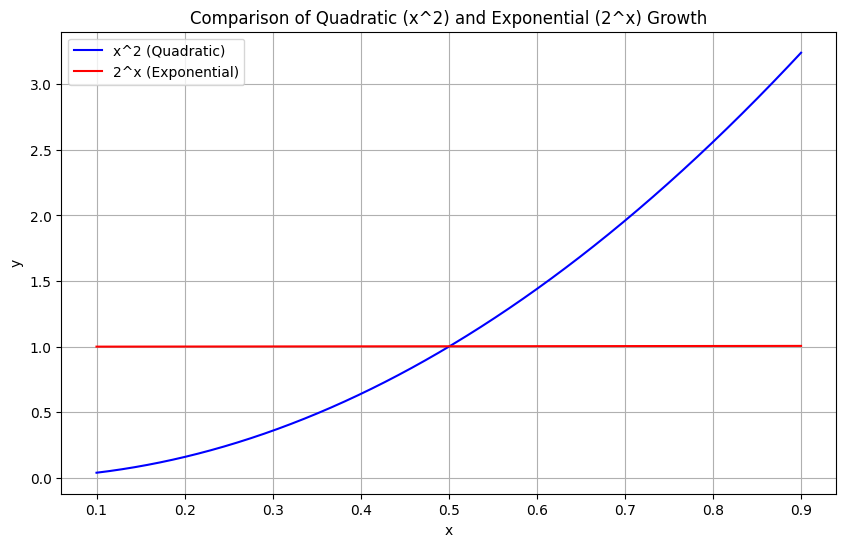

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the data points
x = np.linspace(0.1, 0.9, 1000)
y = 2

y_squared = ((y * x) ** 2) # x squared
y_exponential = 2 ** (0.01 * x)  # 2 raised to the power of x

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(x, y_squared, label="x^2 (Quadratic)", color="blue")
plt.plot(x, y_exponential, label="2^x (Exponential)", color="red")

# Add labels, title, legend, and grid
plt.title("Comparison of Quadratic (x^2) and Exponential (2^x) Growth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


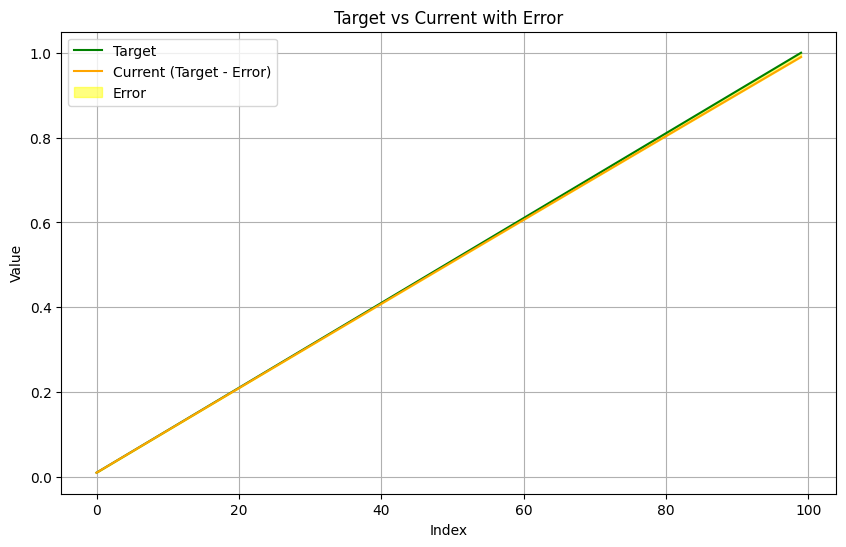

In [13]:
# Re-import necessary libraries after reset
import numpy as np
import matplotlib.pyplot as plt

# Generate the data points
target = np.linspace(0.01, 1.0, 100)  # Target values
error = np.linspace(0.01, 0.1, 100)  # Error values

# Calculate the current values (target - error)
current = target - error ** 2

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(target, label="Target", color="green")
plt.plot(current, label="Current (Target - Error)", color="orange")
plt.fill_between(range(len(target)), current, target, color="yellow", alpha=0.5, label="Error")

# Add labels, title, legend, and grid
plt.title("Target vs Current with Error")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [16]:
pitch, yaw, left_speed, right_speed = 0.075, 0.25, 0.01, -0.01
target_speed = 0.01

speed = (left_speed + right_speed) / 2

reward = 0

# Reward  or penalty by pitch and yaw stability
reward1 = 0.5 - abs(pitch*10)**2
reward2 = 1.0 - ((abs(yaw *10)**2) / 20 )

error_left_speed = target_speed - left_speed
error_right_speed = target_speed - right_speed

reward3 = 1.0 - (abs(error_left_speed - error_right_speed) * 100)
reward4 = 1.0 - (abs(target_speed - speed) * 100)

print(f"\n reward pitch: {reward1},\n reward yaw: {reward2}")
print(f"\n reward wheels {reward3}")
print(f"\n reward speed {reward4}")

#error_speed = target_speed - speed
#error_left_speed = target_speed - left_speed
#error_right_speed = target_speed - right_speed
#
#print(f"\ntarget_speed : {target_speed}, \n speed: {speed}, \n error_speed: {error_speed}, \n error_left_speed: {error_left_speed}, \n error_right_speed: {error_right_speed}")
#
#print(f"target_speed - error_speed: {target_speed - error_speed}")
#print(f"target_speed - error_left_speed: {target_speed - error_left_speed}")
#print(f"target_speed - error_right_speed: {target_speed - error_right_speed}")
#
## Penalize large deviations from target values        
##reward += abs(error_speed)**2 
##reward += -1 if left_speed < (self.target_speed * 50) else -abs(error_left_speed )**2 
##reward += -1 if right_speed < (self.target_speed * 50) else -abs(error_right_speed)**  
#
#
##penalties for diferential on wheels
#reward10 = (left_speed - right_speed) * 10
#print(f"\n differential : {reward10}")
#
##reward mean speed
#reward4 = (target_speed - abs(error_left_speed)) * 10 if left_speed >= (target_speed * 0.5) else -abs(target_speed - abs(error_left_speed)) * 10 
#reward5 = (target_speed - abs(error_right_speed)) * 10 if right_speed >= (target_speed * 0.5) else -abs(target_speed - abs(error_right_speed)) * 10 
#
#reward9 = (reward4 + reward5)/2
#print(f"{reward3} \n {reward4} \n {reward5}")
#print(f"\n reward/penalti speed : {reward9}")

print(f"\ntotal reward : {(reward1+reward2+reward3+reward4)}")



 reward pitch: -0.0625,
 reward yaw: 0.6875

 reward wheels -1.0

 reward speed 0.0

total reward : -0.375


In [2]:
# Input parameter untuk observasi
pitch = 0.07
yaw = 0.000
linear_speed = -0.1210
linear_left_wheel = -0.1800
linear_right_wheel = -0.0620
left_wheel_revolutions = -0.0002
right_wheel_revolutions = -0.0001

prev_pitch = 0.0385
prev_yaw = 0.12500
prev_linear_speed = -0.1210
prev_linear_left_wheel = -0.1800
prev_linear_right_wheel = -0.0620
prev_left_wheel_revolutions = -0.0002
prev_right_wheel_revolutions = -0.0001

# Parameter fungsi reward
target_revolutions = 1.0
target_pitch = 0.05  # 9 degree
target_speed = 0.05  # 0.5 m/s
speed_penalty_factor = 3.0
pitch_penalty_factor = 3.0
yaw_penalty_factor = 3.0


current_revolutions = (left_wheel_revolutions + right_wheel_revolutions) / 2
previous_revolutions = (prev_left_wheel_revolutions + prev_right_wheel_revolutions) / 2

differential_wheels_speed =  (linear_left_wheel - linear_right_wheel)
differential_wheels_revolution = (left_wheel_revolutions - right_wheel_revolutions)


# Perhitungan reward
reward = 0.0

reward -= ((abs(pitch * 10) **2)) * 0.2
reward -= ((abs(yaw * 10) **2)/10) * 0.2
# Insentif untuk pergerakan maju
reward += 0.05 if current_revolutions > previous_revolutions else -0.01
reward += current_revolutions ** 2
# Insentif bertahan lama
reward += 0.05

# 1 - (1 - 0.9)
# 1 - (0.1) = 0.9
# 1 - (1 - 0.1) = 1 - (0.9) = 0.1
# Penalti jika pitch atau yaw melampaui batas
if abs(pitch) > 0.15:  
    reward -= 2.0
    
if abs(yaw) > 0.75:  
    reward -= 2.0

reward


-0.05799997750000002